# Lab 1
## Dynamic model of a multi-link manipulator

## Steps

### 0. Import the necessary libraries

In [192]:
from math import pi
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt

### 1. Import robot model (ABB IRB140)

In [193]:
robot = rtb.models.DH.IRB140()
print(robot)

DHRobot: IRB 140 (by ABB), 6 joints (RRRRRR), dynamics, geometry, standard DH parameters
┌─────┬───────┬──────┬────────┬─────────┬────────┐
│ θⱼ  │  dⱼ   │  aⱼ  │   ⍺ⱼ   │   q⁻    │   q⁺   │
├─────┼───────┼──────┼────────┼─────────┼────────┤
│  q1 │ 0.352 │ 0.07 │ -90.0° │ -180.0° │ 180.0° │
│  q2 │     0 │ 0.36 │   0.0° │ -100.0° │ 100.0° │
│  q3 │     0 │    0 │ -90.0° │ -220.0° │  60.0° │
│  q4 │  0.38 │    0 │  90.0° │ -200.0° │ 200.0° │
│  q5 │     0 │    0 │ -90.0° │ -120.0° │ 120.0° │
│  q6 │ 0.065 │    0 │   0.0° │ -400.0° │ 400.0° │
└─────┴───────┴──────┴────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬─────┬──────┬───────┬─────┬──────┬──────┐
│ name │ q0  │ q1   │ q2    │ q3  │ q4   │ q5   │
├──────┼─────┼──────┼───────┼─────┼──────┼──────┤
│   qr │  0° │ -90° │  90°  │  0° │  90° │ -90° │
│   qz │  0° │  0°  │  0°   │  0° │  0°  │  0°  │
│   qd │  0° │ -90° │  180° │  0° │  0°  │ -90° │
└──────┴─────┴──────┴───────┴─────┴──────┴──────┘



### 2. Fill in the parameters of the robot model (ABB IRB140)

0. Using dyn() you can view the dynamic parameters of each link

In [194]:
print(robot.links[0].dyn())  # initial dynamic parameters of the first link

m     =        35 
r     =     0.028    0.043   -0.089 
        |     0.51   0.0014    0.051 | 
I     = |   0.0014     0.46     0.07 | 
        |    0.051     0.07     0.46 | 
Jm    =         0 
B     =         0 
Tc    =         0(+)        0(-) 
G     =         0 
qlim  =      -3.1 to      3.1


1. Let's define the mass of the links

In [195]:
robot.links[0].m = 12.0
robot.links[1].m = 35.0
robot.links[2].m = 25.0
robot.links[3].m = 18.0
robot.links[4].m = 6.5
robot.links[5].m = 1.5

2. Let's define the center of mass of each link

In [196]:
robot.links[1].r = [ 0.6491, -1.3089,  0.2913]
robot.links[2].r = [ -0.0973, -1.6171,  0.9243]
robot.links[3].r = [ -0.0089,   -0.0867, -1.3649]
robot.links[4].r = [-0.4077,    0.00,   0.00]
robot.links[5].r = [ -0.000602, -0.004162, -0.486737]

3. Let's define the inertia tensor of each link. Filling: [Lxx, Lyy, Lzz, Lxy, Lyz, Lxz]

In [197]:
robot.links[1].I = [0.765, 0.31, 0.78, -0.3,   -0.14, 0.067]
robot.links[2].I = [1.38,  0.364, 1.09, 0.045, -0.31, -0.02]
robot.links[3].I = [0.349, 0.338, 0.014, 0.0,    0.021, 0.002]
robot.links[4].I = [0.005, 0.011, 0.016, 0.0,    0.0,   0.0]
robot.links[5].I = [0.005, 0.005, 0.0006, 0.0,   4e-5,  0.0]

4. Let's set the moment of inertia of the drive

In [198]:
robot.links[0].Jm = 0.0004
robot.links[1].Jm = 0.0004
robot.links[2].Jm = 0.0004
robot.links[3].Jm = 0.0004
robot.links[4].Jm = 0.0004
robot.links[5].Jm = 0.0004

5. Let's define the coefficient of viscous friction of the drive

In [199]:
robot.links[0].B = 0.0015
robot.links[1].B = 0.000817
robot.links[2].B = 0.00138
robot.links[3].B = 0.0000712
robot.links[4].B = 0.0000826
robot.links[5].B = 0.0000367

6. Let's define the coefficient of Coulomb friction of the drive

In [200]:
robot.links[0].Tc = [0.395, -0.435]
robot.links[1].Tc = [0.126, -0.071]
robot.links[2].Tc = [0.132, -0.105]
robot.links[3].Tc = [0.0112, -0.0169]
robot.links[4].Tc = [0.00926, -0.0145]
robot.links[5].Tc = [0.00396, -0.0105]

8. Let's set restrictions on the generalized coordinates for each link

In [201]:
robot.links[0].qlim = [-np.pi, np.pi]
robot.links[1].qlim = [-1.5708, 1.9199]
robot.links[2].qlim = [-4.0143, 0.8727]
robot.links[3].qlim = [-3.4907, 3.4907]
robot.links[4].qlim = [-2.0071, 2.0071]
robot.links[5].qlim = [-6.9813, 6.9813]

### 3. Set the initial and final positions of the robot and plot them

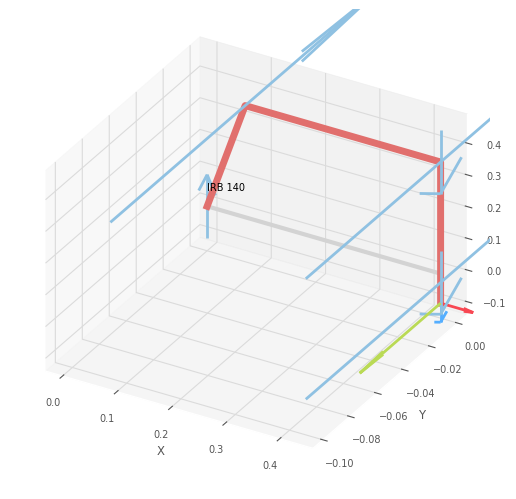

<Figure size 640x480 with 0 Axes>

In [202]:
q_start = [0, 0, 0, 0, 0, 0]
robot.plot(q_start)
plt.show()

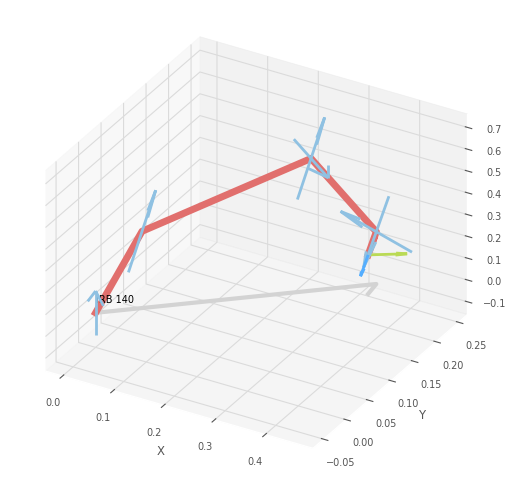

<Figure size 640x480 with 0 Axes>

In [203]:
q_mid = [pi/6, -pi/4, pi/6, -pi/4, pi/6, -pi/4]
robot.plot(q_mid)
plt.show()

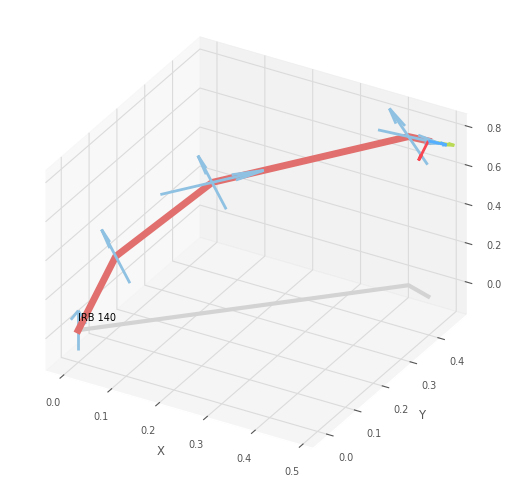

<Figure size 640x480 with 0 Axes>

In [204]:
q_end = [pi/4, -pi/3, -pi/4, pi/3, -pi/3, pi/4]
robot.plot(q_end)
plt.show()

### 4. Plan the trajectory with prebuilt functions

In [205]:
N = 200
t_start = 0
t_mid = 2.5
t_stop = 5
t_shag = t_stop/N
v_mid = np.array([0.1, 0.2, 0.1, -0.5, 0.1, -0.2])
t1 = np.arange(t_start, t_mid, t_shag)
t2 = np.arange(t_mid, t_stop, t_shag)
traj1 = rtb.jtraj(q_start, q_mid, t1, qd0=np.zeros(6), qd1=v_mid)
traj2 = rtb.jtraj(q_mid, q_end, t1, qd0=v_mid, qd1=np.zeros(6))

q = np.vstack((traj1.q, traj2.q))
qd = np.vstack((traj1.qd, traj2.qd))
qdd = np.vstack((traj1.qdd, traj2.qdd))
time = np.concatenate((t1, t2))

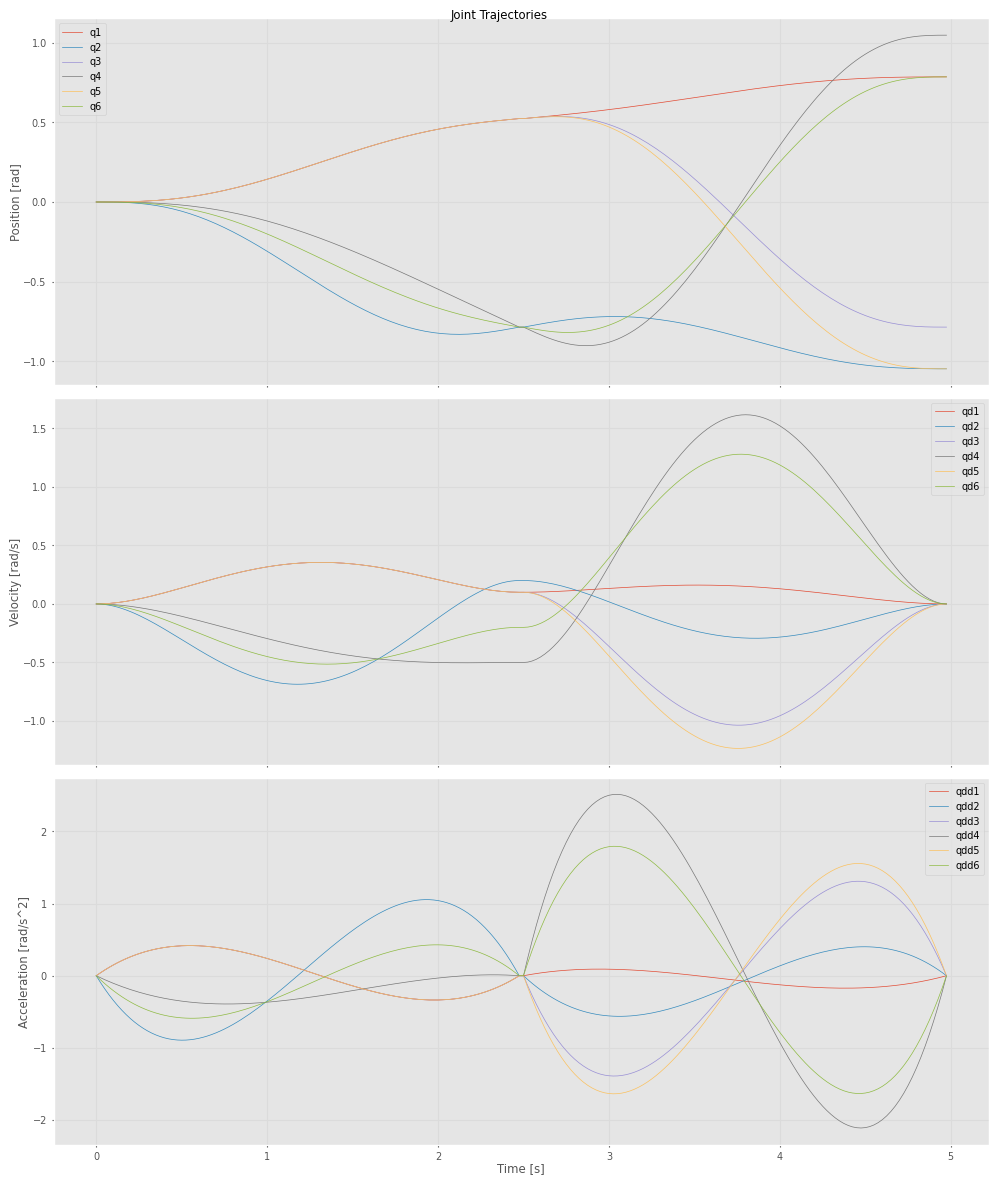

In [207]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
for i in range(6):
    axes[0].plot(time, q[:, i], label=f'q{i+1}')
    axes[1].plot(time, qd[:, i], label=f'qd{i+1}')
    axes[2].plot(time, qdd[:, i], label=f'qdd{i+1}')
axes[0].set_ylabel('Position [rad]')
axes[1].set_ylabel('Velocity [rad/s]')
axes[2].set_ylabel('Acceleration [rad/s^2]')
axes[2].set_xlabel('Time [s]')
for ax in axes:
    ax.grid(True)
    ax.legend()
plt.suptitle('Joint Trajectories')
plt.tight_layout()
plt.show()

### 5. Solve the inverse dynamics

In [208]:
# Case 1: full dynamics (qd != 0, qdd != 0)
tau_full = robot.rne(q, qd, qdd).T

# Case 2: quasi-static (qd != 0, qdd = 0)
tau_quasi = robot.rne(q, qd, np.zeros_like(qdd)).T

# Case 3: static (qd = 0, qdd = 0)
tau_static = robot.rne(q, np.zeros_like(qd), np.zeros_like(qdd)).T

### 6. Obtain the components of the dynamic equation

In [209]:
M = robot.inertia(q)
C = robot.coriolis(q, qd)
G = robot.gravload(q)

In [210]:
normM = np.array([np.linalg.norm(Mi, 'fro') for Mi in M])
normC = np.array([np.linalg.norm(Ci, 'fro') for Ci in C])
normG = np.array([np.linalg.norm(Gi) for Gi in G])

In [211]:
# Condition number of M (ratio of largest to smallest singular value)
condM = np.array([np.linalg.cond(Mi) for Mi in M])

### 7. Plot the graphs

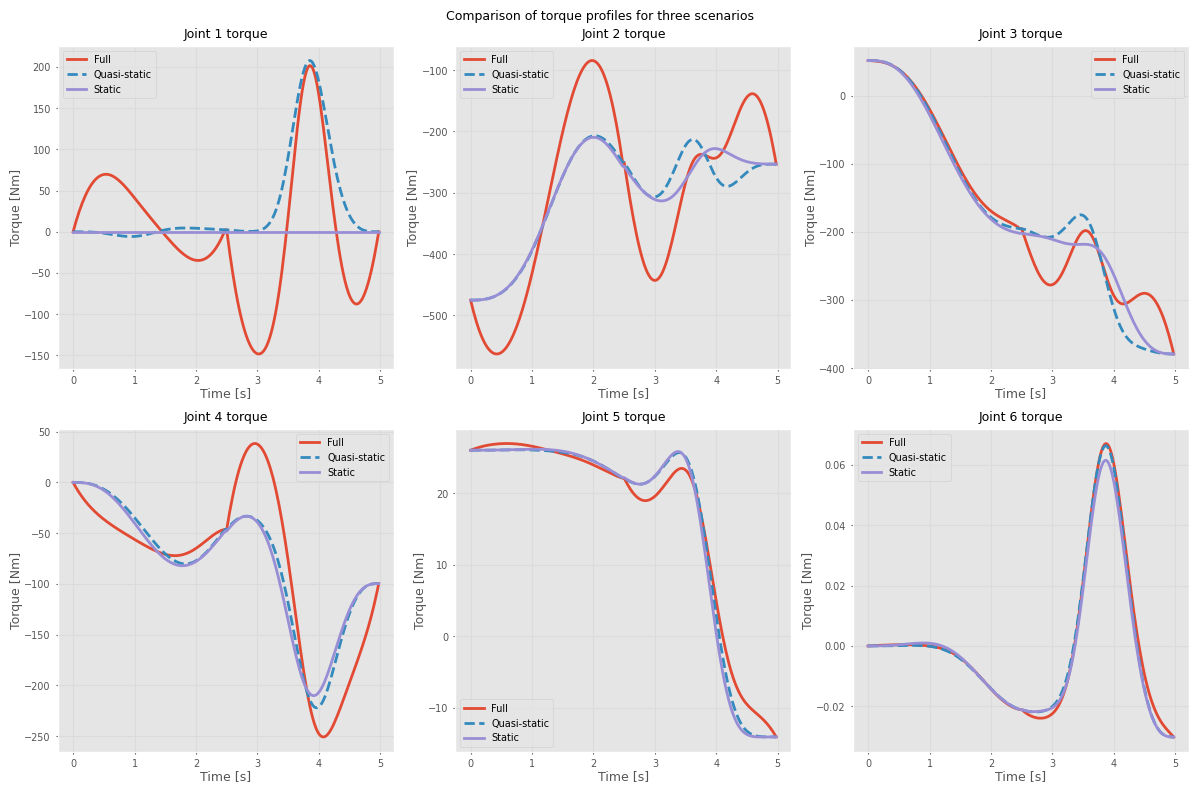

In [212]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for i in range(6):
    axes[i].plot(time, tau_full[i], linewidth=2, label='Full')
    axes[i].plot(time, tau_quasi[i], '--', linewidth=2, label='Quasi-static')
    axes[i].plot(time, tau_static[i], linewidth=2, label='Static')
    axes[i].set_title(f'Joint {i+1} torque', fontsize=9)
    axes[i].set_xlabel('Time [s]', fontsize=9)
    axes[i].set_ylabel('Torque [Nm]', fontsize=9)
    axes[i].grid(True)
    axes[i].legend()
plt.suptitle('Comparison of torque profiles for three scenarios', fontsize=9)
plt.tight_layout()
plt.show()

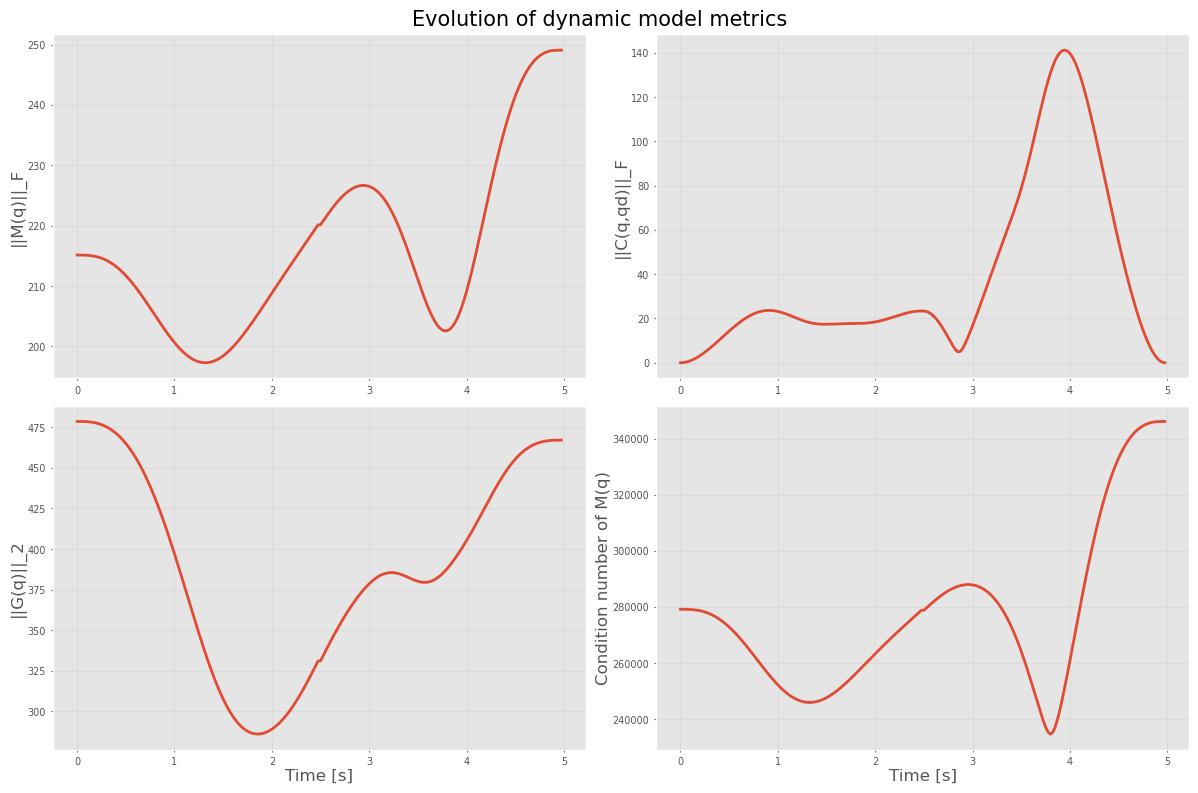

At t=0:
  Norm of M = 215.137
  Norm of C = 0.000
  Norm of G = 478.629
  Condition number of M = 279177.119


In [213]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs[0,0].plot(time, normM, linewidth=2)
axs[0,0].set_ylabel('||M(q)||_F', fontsize=12)
axs[0,0].grid(True)
axs[0,1].plot(time, normC, linewidth=2)
axs[0,1].set_ylabel('||C(q,qd)||_F', fontsize=12)
axs[0,1].grid(True)
axs[1,0].plot(time, normG, linewidth=2)
axs[1,0].set_ylabel('||G(q)||_2', fontsize=12)
axs[1,0].set_xlabel('Time [s]', fontsize=12)
axs[1,0].grid(True)
axs[1,1].plot(time, condM, linewidth=2)
axs[1,1].set_ylabel('Condition number of M(q)', fontsize=12)
axs[1,1].set_xlabel('Time [s]', fontsize=12)
axs[1,1].grid(True)
plt.suptitle('Evolution of dynamic model metrics', fontsize=15)
plt.tight_layout()
plt.show()

# Print some numerical values at initial time
print("At t=0:")
print(f"  Norm of M = {normM[0]:.3f}")
print(f"  Norm of C = {normC[0]:.3f}")
print(f"  Norm of G = {normG[0]:.3f}")
print(f"  Condition number of M = {condM[0]:.3f}")